In [59]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning, module='numpy.ma')

## Investigating Exclusion of Counties that have Existing Plants

In [2]:
final_data = Path.cwd().parent.parent.joinpath('processed_data', 'final_dataset.csv')
candidates_data = Path.cwd().parent.parent.joinpath('processed_data', 'candidates.csv')

In [3]:
# reading final_dataset.csv and candidates.csv
df_final = pd.read_csv(final_data)
df_candidates = pd.read_csv(candidates_data)

In [4]:
# motivating validation more . . .
# identifying plants that survived or were excluded by masking
has_plant = df_final[df_final['plant_count'] > 0]
survived = has_plant[has_plant['geo_id'].isin(df_candidates['geo_id'])]
excluded = has_plant[~has_plant['geo_id'].isin(df_candidates['geo_id'])]

print(f'Plant counties in full dataset: {len(has_plant)}')
print(f'Plant counties surviving masking: {len(survived)}')
print(f'Plant counties excluded by maksing: {len(excluded)}')

Plant counties in full dataset: 54
Plant counties surviving masking: 42
Plant counties excluded by maksing: 12


In [5]:
# finding exclusion reasons
def exclusion_reason(county):
    reasons = []
    if county['pga_max'] > 0.3:
        reasons.append(f'seismic (pga_max={county['pga_max']:.4f})')
    if county['pct_sfha'] > 0.2:
        reasons.append(f'flood (pct_sfha={county['pct_sfha']:.4f})')
    if county['pct_military'] > 0.1:
        reasons.append(f'military (pct_military={county['pct_military']:.4f})')
    if county['pct_protected'] > 0.1:
        reasons.append(f'protected (pct_protected={county['pct_protected']:.4f})')
    return ', '.join(reasons)

excluded = excluded.copy()
excluded['exclusion_reason'] = excluded.apply(exclusion_reason, axis=1)
with pd.option_context('display.max_colwidth', None):
    display(excluded[['county_name', 'exclusion_reason']])

,county_name,exclusion_reason
118,Matagorda County,flood (pct_sfha=0.4517)
464,Coffey County,flood (pct_sfha=0.2101)
691,West Feliciana Parish,flood (pct_sfha=0.3915)
926,Claiborne County,flood (pct_sfha=0.2020)
939,Miami-Dade County,"flood (pct_sfha=0.4680), protected (pct_protected=0.4706)"
1779,San Luis Obispo County,"seismic (pga_max=0.5300), protected (pct_protected=0.1626)"
1918,Maricopa County,"military (pct_military=0.1233), protected (pct_protected=0.1393)"
2197,Brunswick County,flood (pct_sfha=0.3282)
2582,Nemaha County,flood (pct_sfha=0.2122)
2849,Hamilton County,seismic (pga_max=0.3200)


In [6]:
exclusion_counts = {'Seismic': (has_plant['pga_max'] > 0.3).sum(),
                    'Flood': (has_plant['pct_sfha'] > 0.2).sum(),
                    'Military': (has_plant['pct_military'] > 0.1).sum(),
                    'Protected': (has_plant['pct_protected'] > 0.1).sum()}
exclusion_counts

{'Seismic': np.int64(2),
 'Flood': np.int64(9),
 'Military': np.int64(1),
 'Protected': np.int64(4)}

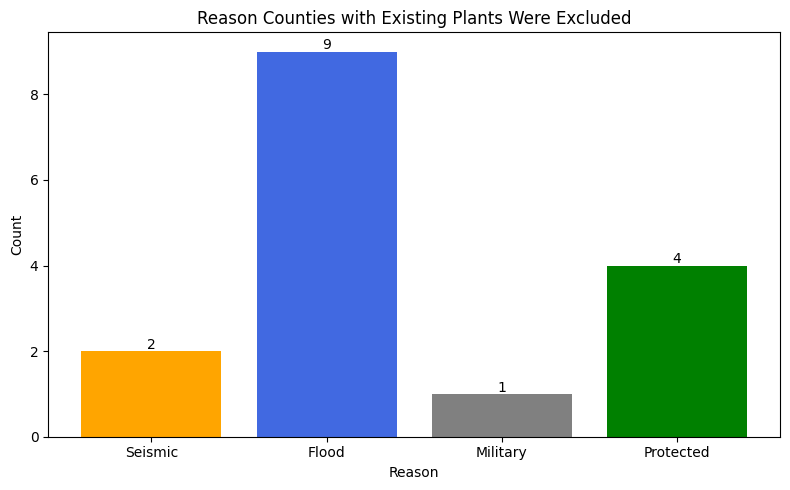

In [7]:
# bar graph of count of reasons why counties with existing plants were excluded

plt.figure(figsize=(8, 5))
plt.bar(exclusion_counts.keys(), exclusion_counts.values(), color=['orange', 'royalblue', 'gray', 'green'])
plt.title('Reason Counties with Existing Plants Were Excluded')
plt.ylabel('Count')
plt.xlabel('Reason')
for i, (k, v) in enumerate(exclusion_counts.items()):
    plt.text(i, v + 0.05, str(v), ha='center')
plt.tight_layout()
plt.show()

## Extracting Feature Importance

In [8]:
candidates_ranked_data = Path.cwd().parent.parent.joinpath('processed_data', 'candidates_ranked.csv')
candidates_ranked_data

WindowsPath('c:/Users/brian/OneDrive - University of Illinois - Urbana/team-nuclear-family/processed_data/candidates_ranked.csv')

In [9]:
df = pd.read_csv(candidates_ranked_data)
df.head()

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0,0.529671,1880.0
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0,0.591694,1349.0
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0,0.637095,799.0
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0,0.585314,1404.0
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0,0.596162,1284.0


In [10]:
# from scoring.ipynb:
# some variables are better if they have a higher value
# while others are better if they have a lower value

higher_better = [
    "avg_vol",
    "total_lake_area", 
    "max_voltage",
    "total_energy_consumption_mwh",
    "data_centers_count"
]

lower_better = [
    "pga_max",
    "pct_sfha",
    "population_density",
    "dist_to_lakes_km",
    "distance_to_lines_km",
    "pct_military",
    "pct_protected",
]

scored_features = higher_better + lower_better
scored_features

['avg_vol',
 'total_lake_area',
 'max_voltage',
 'total_energy_consumption_mwh',
 'data_centers_count',
 'pga_max',
 'pct_sfha',
 'population_density',
 'dist_to_lakes_km',
 'distance_to_lines_km',
 'pct_military',
 'pct_protected']

In [11]:
# places with no mcda_score
df[df['mcda_score'].isna()]

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
155,78030,St. Thomas Island,NaN,NaN,NaN,NaN,0.0,4.057066e+07,0.050775,1,...,0.0,0.000000,20.0,2.299731e+06,0.002878,799.030691,NaN,0,NaN,NaN
226,60040,Swains Island,NaN,NaN,NaN,NaN,0.0,0.000000e+00,0.000000,1,...,0.0,0.000000,0.0,0.000000e+00,0.000000,151.603053,NaN,0,NaN,NaN
297,66010,Guam,NaN,NaN,NaN,NaN,0.0,9.705555e+07,0.065672,1,...,0.0,0.000000,13.0,1.108224e+08,0.074987,1477.893555,NaN,0,NaN,NaN
325,69100,Rota Municipality,NaN,NaN,NaN,NaN,0.0,4.917306e+06,0.007878,0,...,0.0,0.000000,0.0,0.000000e+00,0.000000,624.189588,NaN,0,NaN,NaN
846,69110,Saipan Municipality,NaN,NaN,NaN,NaN,0.0,1.852848e+07,0.028433,1,...,0.0,0.000000,0.0,0.000000e+00,0.000000,651.656085,NaN,0,NaN,NaN
854,9110,Capitol Planning Region,994115.0,88190.0,413960.0,NaN,1.0,1.954939e+08,0.072148,53,...,345.0,141.285714,1114.0,1.005055e+08,0.037092,2709.608749,366.885072,0,NaN,NaN
855,9120,Greater Bridgeport Planning Region,337697.0,83147.0,125378.0,NaN,1.0,6.009566e+07,0.097426,10,...,345.0,125.000000,73.0,1.494759e+07,0.024233,616.832049,547.469932,0,NaN,NaN
856,9130,Lower Connecticut River Valley Planning Region,177311.0,99742.0,82618.0,NaN,0.0,1.643571e+08,0.122696,35,...,345.0,191.666667,711.0,8.471923e+07,0.063245,1339.543612,132.366724,0,NaN,NaN
857,9140,Naugatuck Valley Planning Region,463349.0,82939.0,191666.0,NaN,0.0,4.851334e+07,0.044432,30,...,345.0,119.893617,337.0,3.754786e+07,0.034389,1091.854238,424.368917,0,NaN,NaN
858,9150,Northeastern Connecticut Planning Region,98096.0,83119.0,41503.0,NaN,0.0,6.902615e+07,0.047325,47,...,345.0,161.000000,192.0,4.674583e+07,0.032049,1458.569142,67.254954,0,NaN,NaN


In [12]:
# dropping places with no mcda_score
df = df.dropna(subset=['mcda_score'])
print(f'Total candidates: {len(df)}')
print(f'Has plant: {df["has_plant"].sum()}')
print(f'No plant:  {(df["has_plant"]==0).sum()}')

Total candidates: 2141
Has plant: 41
No plant:  2100


Southeastern Connecticut Planning Region, which has an operating nuclear plant, was dropped as it does not have an mcda_score due to no total energy consumption data for it in our dataset. This can be something to investigate.

### Decision Tree

In [13]:
# checking for null values in scored features
print(df[scored_features].isna().sum().sum())

0


In [14]:
# creating features and target
from sklearn.pipeline import Pipeline
X = df[scored_features]
y = df['has_plant']

# creating train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=207)

In [15]:
# cross validation
# class_weight='balanced' to handle class imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=207)
tree = DecisionTreeClassifier(class_weight='balanced', random_state=207)

# creating pipeline
pipeline = Pipeline([('scaler', MinMaxScaler()), ('tree', tree)])

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
print(f'Baseline F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Baseline F1: 0.0697 ± 0.0855


In [16]:
# grid search
params = {'tree__max_depth': [3, 5, 7, 10, None], 'tree__min_samples_split': [2, 5, 10], 'tree__min_samples_leaf': [1, 2, 4], 'tree__criterion': ['gini', 'entropy'], 'tree__max_features': ['sqrt', 'log2', None]}
grid_search = GridSearchCV(pipeline, params, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best F1:', grid_search.best_score_)
print('Best CV std:', grid_search.cv_results_['std_test_score'][grid_search.best_index_])

Best params: {'tree__criterion': 'gini', 'tree__max_depth': None, 'tree__max_features': 'sqrt', 'tree__min_samples_leaf': 4, 'tree__min_samples_split': 2}
Best F1: 0.10998357963875205
Best CV std: 0.14099575892266433


After grid search, F1 score is still low. This suggests that the features used may not strongly predict historical plant siting.

In [17]:
# tree with best params
best_tree = grid_search.best_estimator_

y_pred = best_tree.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No plant', 'Has plant']))

              precision    recall  f1-score   support

    No plant       0.98      0.96      0.97       421
   Has plant       0.06      0.12      0.08         8

    accuracy                           0.95       429
   macro avg       0.52      0.54      0.53       429
weighted avg       0.97      0.95      0.96       429



Precision and recall for 'has plant' is low, so the tree flagged many counties with no operating plants as ones that do and flagged many counties with operating plants as ones that don't.

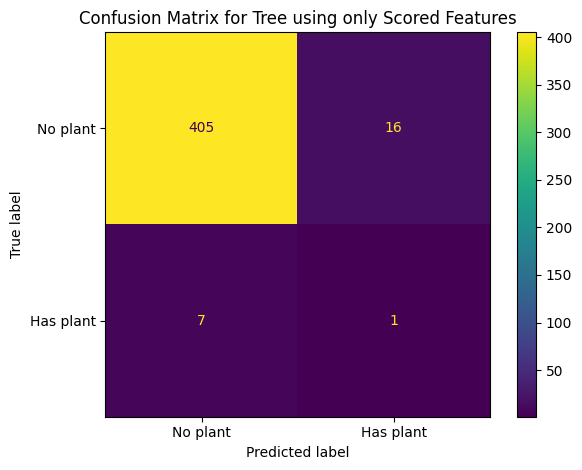

In [18]:
# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test, display_labels=['No plant', 'Has plant'])
plt.title('Confusion Matrix for Tree using only Scored Features')
plt.tight_layout()
plt.show()

In [19]:
# feature importances
tree_importances = pd.DataFrame({'feature': scored_features, 'importance': (best_tree.named_steps['tree'].feature_importances_).round(9)}).sort_values('importance', ascending=False)
tree_importances

,feature,importance
3,total_energy_consumption_mwh,0.199882
8,dist_to_lakes_km,0.194669
2,max_voltage,0.153813
1,total_lake_area,0.124757
9,distance_to_lines_km,0.098039
6,pct_sfha,0.097322
5,pga_max,0.079790
7,population_density,0.023171
11,pct_protected,0.017736
0,avg_vol,0.010822


`data_centers_count` and `pct_military` have low importances, possibly suggesting these weren't important factors for siting historical plants or may be highly correlated with other variables.

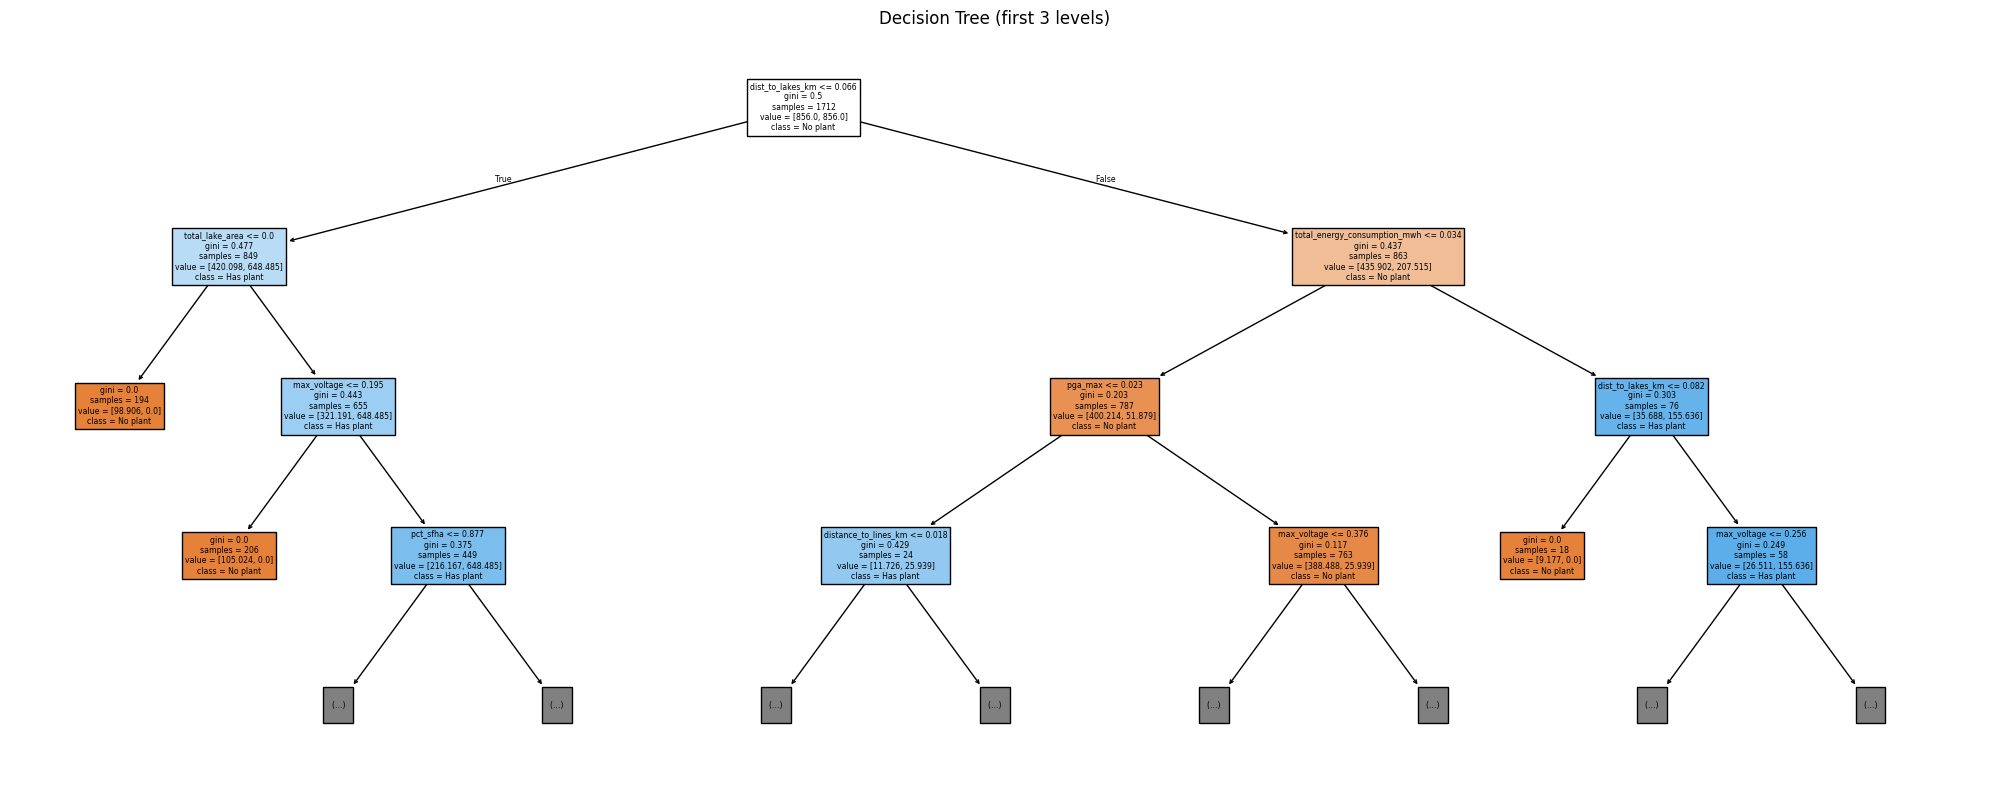

In [20]:
# visualize the tree
plt.figure(figsize=(20, 8))
plot_tree(
    best_tree.named_steps['tree'],
    feature_names=scored_features,
    class_names=['No plant', 'Has plant'],
    filled=True,
    max_depth=3
)
plt.title('Decision Tree (first 3 levels)')
plt.tight_layout()
plt.show()

In [21]:
# Definining decision tree function to use on different dataframes and features
    # returns best tree (pipeline), importances dataframe, and classification report
def make_decision_tree(df: pd.DataFrame, features: list, params: dict):
    """ 
    Returns: 
    
    best_tree: Pipeline

    tree_importances: pd.Dataframe

    report: dict
    """
    df = df.dropna(subset=features)
    # features and target
    X = df[features]
    y = df['has_plant']

    # split into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=207)

    # cross validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=207)
    tree = DecisionTreeClassifier(class_weight='balanced', random_state=207)
    pipeline = Pipeline([('scaler', MinMaxScaler()), ('tree', tree)])
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    print(f'Baseline F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # add tree__ prefix before each of the params
    prefixed_params = {f'tree__{k}': v for k, v in params.items()}

    # grid search
    grid_search = GridSearchCV(pipeline, prefixed_params, cv=cv, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print('Best params:', grid_search.best_params_)
    print('Best F1:', grid_search.best_score_)
    print('Best CV std:', grid_search.cv_results_['std_test_score'][grid_search.best_index_])

    # fit and evaluate on test data
    best_tree = grid_search.best_estimator_
    y_pred = best_tree.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=['No plant', 'Has plant'], output_dict=True)
    print(classification_report(y_test, y_pred, target_names=['No plant', 'Has plant']))

    '''
    # confusion matrix
    ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test, display_labels=['No plant', 'Has plant'])
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    '''

    # feature importances
    tree_importances = pd.DataFrame({'feature': features, 'importance': (best_tree.named_steps['tree'].feature_importances_).round(9)}).sort_values('importance', ascending=False)

    return best_tree, tree_importances, report

In [22]:
params = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 
              'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy'], 
              'max_features': ['sqrt', 'log2', None]}
best_tree_all_vars, importances_all_vars, report = make_decision_tree(df, df.columns.drop(['geo_id', 'county_name', 'plant_count', 'has_plant', 'mcda_score', 'rank']).to_list(), params)
importances_all_vars

Baseline F1: 0.0802 ± 0.0658
Best params: {'tree__criterion': 'entropy', 'tree__max_depth': None, 'tree__max_features': 'log2', 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 10}
Best F1: 0.175
Best CV std: 0.10488088481701516
              precision    recall  f1-score   support

    No plant       0.98      0.96      0.97       420
   Has plant       0.00      0.00      0.00         8

    accuracy                           0.94       428
   macro avg       0.49      0.48      0.48       428
weighted avg       0.96      0.94      0.95       428



,feature,importance
3,total_energy_consumption_mwh,0.208564
29,population_density,0.085360
23,max_voltage,0.080049
10,avg_depth,0.073351
8,total_lake_area,0.061825
16,total_rivers_mile,0.061057
13,wetland_count,0.058067
24,average_voltage,0.054931
9,avg_vol,0.050810
5,sfha_area,0.046041


Both decision trees so far put `total_energy_consumption_mwh` as the most important feature.
The decision tree using all features predicts none of the counties with operating plants correctly. Removing None from max_depth possibilities since None gets chosen and may cause overfitting.

In [23]:
# comparing scored_features vs. all features with and without max_depth=None in grid search

# have scored_features from before
all_features = df.columns.drop(['geo_id', 'county_name', 'plant_count', 'has_plant', 'mcda_score', 'rank']).to_list()

params_with_max_depth_none = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 
              'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy'], 
              'max_features': ['sqrt', 'log2', None]}
params_without_max_depth_none = params = {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10], 
              'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy'], 
              'max_features': ['sqrt', 'log2', None]}

print("Scored features with max_depth=None in grid search: ")
_, importances_scored_with, report_scored_with = make_decision_tree(df, scored_features, params_with_max_depth_none)
print("Scored features without max_depth=None in grid search: ")
_, importances_scored_without, report_scored_without = make_decision_tree(df, scored_features, params_without_max_depth_none)
print("All features with max_depth=None in grid search: ")
_, importances_all_with, report_all_with = make_decision_tree(df, all_features, params_with_max_depth_none)
print("All features without max_depth=None in grid search: ")
_, importances_all_without, report_all_without = make_decision_tree(df, all_features, params_without_max_depth_none)

Scored features with max_depth=None in grid search: 
Baseline F1: 0.0697 ± 0.0855
Best params: {'tree__criterion': 'gini', 'tree__max_depth': None, 'tree__max_features': 'sqrt', 'tree__min_samples_leaf': 4, 'tree__min_samples_split': 2}
Best F1: 0.10998357963875205
Best CV std: 0.14099575892266433
              precision    recall  f1-score   support

    No plant       0.98      0.96      0.97       421
   Has plant       0.06      0.12      0.08         8

    accuracy                           0.95       429
   macro avg       0.52      0.54      0.53       429
weighted avg       0.97      0.95      0.96       429

Scored features without max_depth=None in grid search: 
Baseline F1: 0.0697 ± 0.0855
Best params: {'tree__criterion': 'gini', 'tree__max_depth': 10, 'tree__max_features': 'sqrt', 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 5}
Best F1: 0.10046398046398046
Best CV std: 0.0645894827539592
              precision    recall  f1-score   support

    No plant       0

In [24]:
comparison = pd.DataFrame([
    {
        'tree': 'Scored features with None',
        'baseline_f1': 0.0697,
        'baseline_std': 0.0855,
        'best_cv_f1': 0.1100,
        'best_cv_std': 0.1410,
        **{k: round(v, 4) for k, v in {
            'no_plant_precision': report_scored_with['No plant']['precision'],
            'no_plant_recall': report_scored_with['No plant']['recall'],
            'no_plant_f1': report_scored_with['No plant']['f1-score'],
            'has_plant_precision': report_scored_with['Has plant']['precision'],
            'has_plant_recall': report_scored_with['Has plant']['recall'],
            'has_plant_f1': report_scored_with['Has plant']['f1-score'],
        }.items()}
    },
    {
        'tree': 'Scored features without None',
        'baseline_f1': 0.0697,
        'baseline_std': 0.0855,
        'best_cv_f1': 0.1005,
        'best_cv_std': 0.0646,
        **{k: round(v, 4) for k, v in {
            'no_plant_precision': report_scored_without['No plant']['precision'],
            'no_plant_recall': report_scored_without['No plant']['recall'],
            'no_plant_f1': report_scored_without['No plant']['f1-score'],
            'has_plant_precision': report_scored_without['Has plant']['precision'],
            'has_plant_recall': report_scored_without['Has plant']['recall'],
            'has_plant_f1': report_scored_without['Has plant']['f1-score'],
        }.items()}
    },
    {
        'tree': 'All features with None',
        'baseline_f1': 0.0802,
        'baseline_std': 0.0658,
        'best_cv_f1': 0.175,
        'best_cv_std': 0.105,
        **{k: round(v, 4) for k, v in {
            'no_plant_precision': report_all_with['No plant']['precision'],
            'no_plant_recall': report_all_with['No plant']['recall'],
            'no_plant_f1': report_all_with['No plant']['f1-score'],
            'has_plant_precision': report_all_with['Has plant']['precision'],
            'has_plant_recall': report_all_with['Has plant']['recall'],
            'has_plant_f1': report_all_with['Has plant']['f1-score'],
        }.items()}
    },
    {
        'tree': 'All features without None',
        'baseline_f1': 0.0802,
        'baseline_std': 0.0658,
        'best_cv_f1': 0.1459,         
        'best_cv_std': 0.0451,        
        **{k: round(v, 4) for k, v in {
            'no_plant_precision': report_all_without['No plant']['precision'],
            'no_plant_recall': report_all_without['No plant']['recall'],
            'no_plant_f1': report_all_without['No plant']['f1-score'],
            'has_plant_precision': report_all_without['Has plant']['precision'],
            'has_plant_recall': report_all_without['Has plant']['recall'],
            'has_plant_f1': report_all_without['Has plant']['f1-score'],
        }.items()}
    },
]).set_index('tree')

comparison

,baseline_f1,baseline_std,best_cv_f1,best_cv_std,no_plant_precision,no_plant_recall,no_plant_f1,has_plant_precision,has_plant_recall,has_plant_f1
tree,,,,,,,,,,
Scored features with None,0.0697,0.0855,0.1100,0.1410,0.9830,0.9620,0.9724,0.0588,0.125,0.0800
Scored features without None,0.0697,0.0855,0.1005,0.0646,0.9843,0.8931,0.9365,0.0426,0.250,0.0727
All features with None,0.0802,0.0658,0.1750,0.1050,0.9805,0.9595,0.9699,0.0000,0.000,0.0000
All features without None,0.0802,0.0658,0.1459,0.0451,0.9825,0.9357,0.9585,0.0357,0.125,0.0556


Removing None from max_depth possibilities decreases F1 score slightly but decreases std for both decision trees, which decreases instability. For the tree using all features, precision and recall for 'has plant' improves from 0.

In [25]:
# all feature importances
all_importances = pd.concat([df.reset_index(drop=True) for df in [importances_scored_with, importances_scored_without, importances_all_with, importances_all_without]], axis=1, 
          keys=["Scored features with None", "Scored features without None", "All features with None", "All features without None"]).fillna("")
all_importances.index += 1
all_importances

Scored features with None             Scored features without None  \
                         feature importance                       feature   
1   total_energy_consumption_mwh   0.199882                   max_voltage   
2               dist_to_lakes_km   0.194669                      pct_sfha   
3                    max_voltage   0.153813               total_lake_area   
4                total_lake_area   0.124757            population_density   
5           distance_to_lines_km   0.098039              dist_to_lakes_km   
6                       pct_sfha   0.097322          distance_to_lines_km   
7                        pga_max    0.07979                       avg_vol   
8             population_density   0.023171                  pct_military   
9                  pct_protected   0.017736                       pga_max   
10                       avg_vol   0.010822  total_energy_consumption_mwh   
11            data_centers_count        0.0            data_centers_count   
12                  pct_military        0.0                 pct_protected   
13                                                                          
14                                                                          
15                                                                          
16                                                                          
17                                                                          
18                                                                          
19                                                                          
20                                                                          
21                                                                          
22                                                                          
23                                                                          
24                                                                          
25                                                                          
26                                                                          
27                                                                          
28                                                                          
29                                                                          
30                                                                          

                     All features with None             \
   importance                       feature importance   
1    0.183393  total_energy_consumption_mwh   0.208564   
2    0.161211            population_density   0.085360   
3    0.146491                   max_voltage   0.080049   
4    0.142623                     avg_depth   0.073351   
5    0.110925               total_lake_area   0.061825   
6    0.092714             total_rivers_mile   0.061057   
7    0.051226                 wetland_count   0.058067   
8    0.050161               average_voltage   0.054931   
9    0.029483                       avg_vol   0.050810   
10   0.023877                     sfha_area   0.046041   
11    0.00398                       pga_max   0.045512   
12   0.003916               protected_count   0.039479   
13                   total_protected_area_m   0.027445   
14                 transmission_lines_count   0.025772   
15                  median_household_income   0.022036   
16                                 pct_sfha   0.020062   
17                               lake_count   0.018895   
18                     distance_to_lines_km   0.010247   
19                               population   0.006175   
20                            housing_units   0.002417   
21                             rivers_count   0.001904   
22                       data_centers_count   0.000000   
23                         dist_to_lakes_km   0.000000   
24                            avg_discharge   0.000000   
25                    distance_to_

Some insights:
- `total_energy_consumption_mwh` consistently ranks as top feature for 3 of the 4 trees
- `max_voltage` also ranks high but drops for "All features - without None," possibly due to correlated variables in all features
- `data_centers_count` ranks low, with zero or near-zero importance across all trees; this may mean that it did not influence historical siting
- there is likely multicollinearity influencing the importances of variables, especially in the trees using all features


### XG Boost

In [26]:
# handles class imbalance
scale_pos_weight = (df['has_plant'] == 0).sum() / (df['has_plant'] == 1).sum()


X = df[scored_features]
y = df['has_plant']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=207)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=207)

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=207, eval_metric='logloss')
pipeline_xgb = Pipeline([('scaler', MinMaxScaler()), ('xgb', xgb)])

cv_scores_xgb = cross_val_score(pipeline_xgb, X_train, y_train, cv=cv, scoring='f1')
print(f'Baseline F1:  {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}')

Baseline F1:  0.0400 ± 0.0800


In [27]:
params_xgb = {'n_estimators': [100, 200, 300], 'max_depth': [3, 4, 5, 6], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'subsample': [0.6, 0.8, 1.0], 'colsample_bytree': [0.6, 0.8, 1.0]}
prefixed_params_xgb = {f'xgb__{k}': v for k,v in params_xgb.items()}

grid_search_xgb = GridSearchCV(pipeline_xgb, prefixed_params_xgb, cv=cv, scoring='f1', n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

print('Best params:', grid_search_xgb.best_params_)
print('Best F1:', grid_search_xgb.best_score_)
print('Best CV std:', grid_search_xgb.cv_results_['std_test_score'][grid_search_xgb.best_index_])

Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
Best F1: 0.15349157206742345
Best CV std: 0.046629788146919135


In [28]:
best_xgb = grid_search_xgb.best_estimator_
y_pred = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No plant', 'Has plant']))

              precision    recall  f1-score   support

    No plant       0.99      0.95      0.97       421
   Has plant       0.12      0.38      0.18         8

    accuracy                           0.93       429
   macro avg       0.55      0.66      0.57       429
weighted avg       0.97      0.93      0.95       429



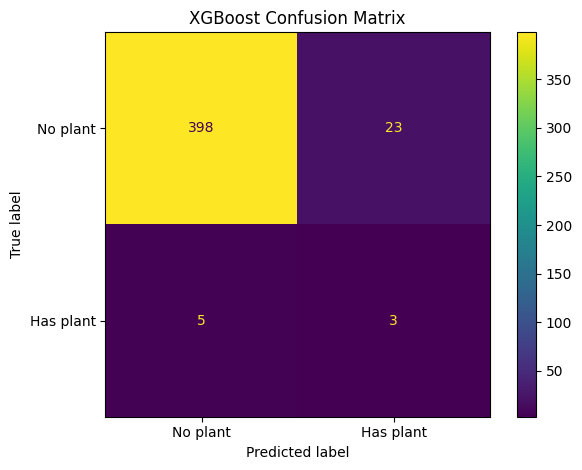

In [29]:
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, display_labels=['No plant', 'Has plant'])
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

In [30]:
xgb_importances = pd.DataFrame({'feature': scored_features, 'importance': best_xgb.named_steps['xgb'].feature_importances_}).sort_values('importance', ascending=False)
xgb_importances

,feature,importance
2,max_voltage,0.292733
7,population_density,0.130095
3,total_energy_consumption_mwh,0.093135
6,pct_sfha,0.074500
1,total_lake_area,0.071281
5,pga_max,0.067277
0,avg_vol,0.056180
10,pct_military,0.048927
8,dist_to_lakes_km,0.048775
11,pct_protected,0.044991


Some findings:
- Both F1 score and std improve for XGBoost compared to decision tree
- More counties with existing plants are predicted correctly
- `max_voltage` still has high importance
- `data_centers_count` has a non_zero importance although it is still the lowest of all scored_features

In [31]:
# defining function for XGBoost 
    # returns best xgb (pipeline), importances dataframe, and classification report
def make_xgboost(df: pd.DataFrame, features: list, params: dict):
    """ 
    Returns: 
    
    best_xgb: Pipeline

    tree_importances: pd.Dataframe

    report: dict
    """
    df = df.dropna(subset=features)
    
    # features and target
    X = df[features]
    y = df['has_plant']

    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    # split into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=207)

    # cross validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=207)
    xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=207, eval_metric='logloss')
    
    pipeline_xgb = Pipeline([('scaler', MinMaxScaler()), ('xgb', xgb)])
    cv_scores = cross_val_score(pipeline_xgb, X_train, y_train, cv=cv, scoring='f1')
    print(f'Baseline F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # add xgb__ prefix before each of the params
    prefixed_params = {f'xgb__{k}': v for k, v in params.items()}

    # grid search
    grid_search = GridSearchCV(pipeline_xgb, prefixed_params, cv=cv, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print('Best params:', grid_search.best_params_)
    print('Best F1:', grid_search.best_score_)
    print('Best CV std:', grid_search.cv_results_['std_test_score'][grid_search.best_index_])

    # fit and evaluate on test data
    best_xgb = grid_search.best_estimator_
    y_pred = best_xgb.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=['No plant', 'Has plant'], output_dict=True)
    print(classification_report(y_test, y_pred, target_names=['No plant', 'Has plant']))

    '''
    # confusion matrix
    ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, display_labels=['No plant', 'Has plant'])
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    '''

    # feature importances
    importances = pd.DataFrame({'feature': features, 'importance': (best_xgb.named_steps['xgb'].feature_importances_).round(9)}).sort_values('importance', ascending=False)

    return best_xgb, importances, report

In [32]:
# running xgboost on all features (runs slow)

best_xgb_all, xgb_importances_all, report_xgb_all = make_xgboost(df, all_features, params_xgb)

Baseline F1: 0.0500 ± 0.1000
Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Best F1: 0.19454265541222063
Best CV std: 0.06290067914247306
              precision    recall  f1-score   support

    No plant       0.98      0.96      0.97       420
   Has plant       0.05      0.12      0.07         8

    accuracy                           0.94       428
   macro avg       0.52      0.54      0.52       428
weighted avg       0.97      0.94      0.95       428



Using all features, precision and recall dropped, likely meaning that xgboost overfitted with all the features.

In [33]:
# all feature importances - decision tree and xgboost
importances_dt_xgb = pd.concat([df.reset_index(drop=True) for df in [importances_scored_with, importances_scored_without, importances_all_with, importances_all_without, xgb_importances, xgb_importances_all]], axis=1, 
          keys=["DT: Scored features with None", "DT: Scored features without None", "DT: All features with None", "DT: All features without None", "XGBoost: Scored features", "XGBoost: All features"]).fillna("")
importances_dt_xgb.index += 1
importances_dt_xgb

DT: Scored features with None            DT: Scored features without None  \
                         feature importance                          feature   
1   total_energy_consumption_mwh   0.199882                      max_voltage   
2               dist_to_lakes_km   0.194669                         pct_sfha   
3                    max_voltage   0.153813                  total_lake_area   
4                total_lake_area   0.124757               population_density   
5           distance_to_lines_km   0.098039                 dist_to_lakes_km   
6                       pct_sfha   0.097322             distance_to_lines_km   
7                        pga_max    0.07979                          avg_vol   
8             population_density   0.023171                     pct_military   
9                  pct_protected   0.017736                          pga_max   
10                       avg_vol   0.010822     total_energy_consumption_mwh   
11            data_centers_count        0.0               data_centers_count   
12                  pct_military        0.0                    pct_protected   
13                                                                             
14                                                                             
15                                                                             
16                                                                             
17                                                                             
18                                                                             
19                                                                             
20                                                                             
21                                                                             
22                                                                             
23                                                                             
24                                                                             
25                                                                             
26                                                                             
27                                                                             
28                                                                             
29                                                                             
30                                                                             

                 DT: All features with None             \
   importance                       feature importance   
1    0.183393  total_energy_consumption_mwh   0.208564   
2    0.161211            population_density   0.085360   
3    0.146491                   max_voltage   0.080049   
4    0.142623                     avg_depth   0.073351   
5    0.110925               total_lake_area   0.061825   
6    0.092714             total_rivers_mile   0.061057   
7    0.051226                 wetland_count   0.058067   
8    0.050161               average_voltage   0.054931   
9    0.029483                       avg_vol   0.050810   
10   0.023877                     sfha_area   0.046041   
11    0.00398                       pga_max   0.045512   
12   0.003916               protected_count   0.039479   
13                   total_protected_area_m   0.027445   
14                 transmission_lines_count   0.025772   
15                  median_household_income   0.022036   
16                                 pct_sfha   0.020062   
17                               lake_count   0.018895   
18                     distance_to_lines_km   0.010247   
19                               population   0.006175   
20                            housing_units   0.002417   
21                             rivers_count   0.001904   
22                       data_centers_count   0.000000   
23                         dist_to_lakes_km   0.00

Insights:
- `max_voltage` continues to rank high 
- `population_density` consistently ranks high for 5 of the 6 validation models
- `data_centers_count` remains having the lowest importance
- `pga_max` ranks moderately high, but not as high as number 1 (as in scoring.ipynb), suggesting that seismic risk may not have been weighted highly for historical siting

In [34]:
# using SHAP to interpret XGBoost model that uses scored features

# renaming variables
feature_labels = {
    'avg_vol': 'Avg Water Volume',
    'total_lake_area': 'Total Lake Area',
    'max_voltage': 'Max Voltage',
    'total_energy_consumption_mwh': 'Energy Consumption',
    'data_centers_count': 'Data Centers',
    'pga_max': 'Seismic Risk (PGA)',
    'pct_sfha': 'Flood Hazard (SFHA) %',
    'population_density': 'Population Density',
    'dist_to_lakes_km': 'Distance to Lakes',
    'distance_to_lines_km': 'Distance to Lines',
    'pct_military': 'Military Land %',
    'pct_protected': 'Protected Land %'
}


# creating explainer
explainer = shap.TreeExplainer(best_xgb.named_steps['xgb'])
shap_explanation = explainer(pd.DataFrame(best_xgb.named_steps['scaler'].transform(X_train), columns=scored_features))
shap_explanation.feature_names = [feature_labels[f] for f in scored_features]

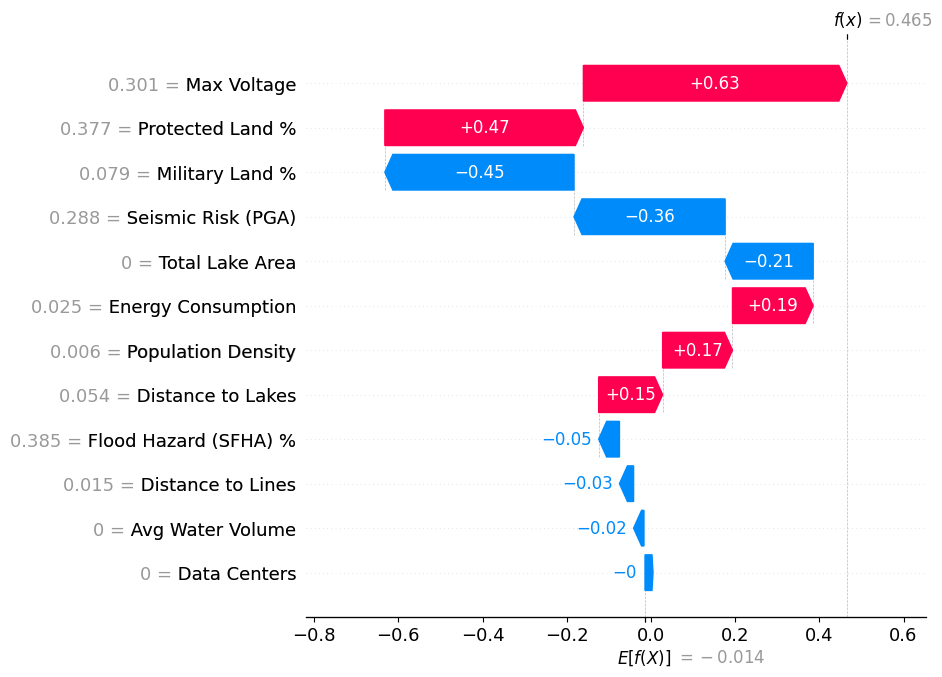

In [35]:
shap.plots.waterfall(shap_explanation[0], max_display=len(scored_features))

For this county (index 0), `pct_protected` pushing prediction toward the plant is counterintuitive here. `total_lake_area` = 0 pushes prediction away from plant; no lakes is bad!

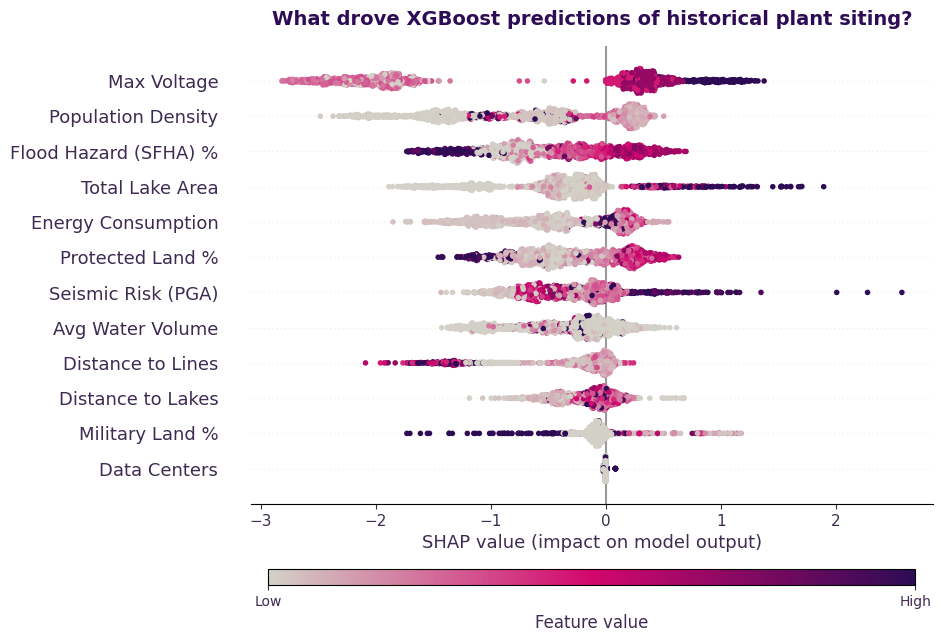

In [70]:
# beeswarm
cmap = mcolors.LinearSegmentedColormap.from_list(
    'deck_colors',
    ['#F2B8D8', '#D4699E', '#3D2B52']
)#D3D1C7

cmap = mcolors.LinearSegmentedColormap.from_list(
    'deck_colors',
    ['#D3D1C7', '#D3076D', '#2E0B55']
)

# beeswarm call — styling comes AFTER this
shap.plots.beeswarm(shap_explanation, max_display=len(scored_features), 
                    show=False, plot_size=(11, 7), color=cmap)

# now grab axes and style
ax = plt.gca()
fig = plt.gcf()
ax.set_title('What drove XGBoost predictions of historical plant siting?',
             color='#2E0B55', fontsize=14, fontweight='bold', pad=15)

for label in ax.get_yticklabels():
    label.set_color('#3D2B52')
for label in ax.get_xticklabels():
    label.set_color('#3D2B52')
for ax_cb in fig.axes:
    if ax_cb != ax:
        ax_cb.remove()

# add a new horizontal colorbar at the bottom
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', 
                    fraction=0.03, pad=0.12, aspect=40)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.ax.xaxis.label.set_color('#3D2B52')
cbar.ax.tick_params(colors='#3D2B52')
cbar.set_label('Feature value', color='#3D2B52', fontsize=12)


ax.xaxis.label.set_color('#3D2B52')


High `max_voltage` (red dots) logically push counties toward having a plant while low `max_voltage` (blue dots) push counties toward not having a plant. There are red dots for `pct_sfha` (high flood risk) on both sides; might be because existing plants were sited near bodies of water, which have flood risk.

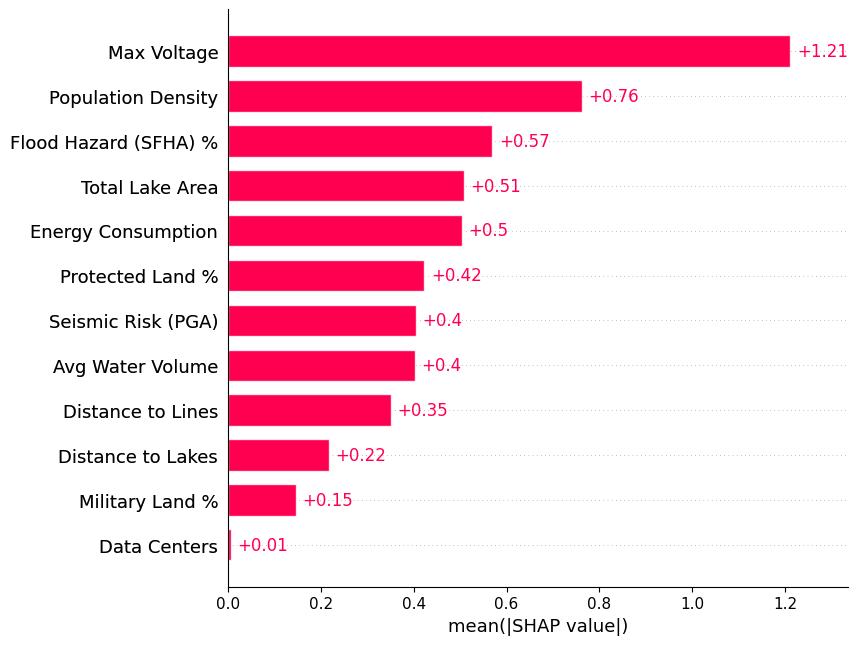

In [37]:
shap.plots.bar(shap_explanation, max_display=len(scored_features))

### Permutation Importances

In [38]:
# measuring each feature's impact on predictions
from sklearn.inspection import permutation_importance

permutation_importance = permutation_importance(best_xgb, X_test, y_test,
                                                n_repeats=30, random_state=207, scoring='f1')
permutation_importance_df = pd.DataFrame({'feature': scored_features, 'importance_mean': permutation_importance.importances_mean.round(9), 'importance_std': permutation_importance.importances_std.round(9)}).sort_values('importance_mean', ascending=False)
permutation_importance_df

,feature,importance_mean,importance_std
2,max_voltage,0.037901,0.094252
1,total_lake_area,0.024617,0.057630
0,avg_vol,0.018386,0.040322
9,distance_to_lines_km,0.016087,0.030466
11,pct_protected,0.015571,0.027830
4,data_centers_count,0.000000,0.000000
7,population_density,-0.003459,0.070939
8,dist_to_lakes_km,-0.007568,0.008263
6,pct_sfha,-0.008390,0.020687
5,pga_max,-0.015538,0.032280


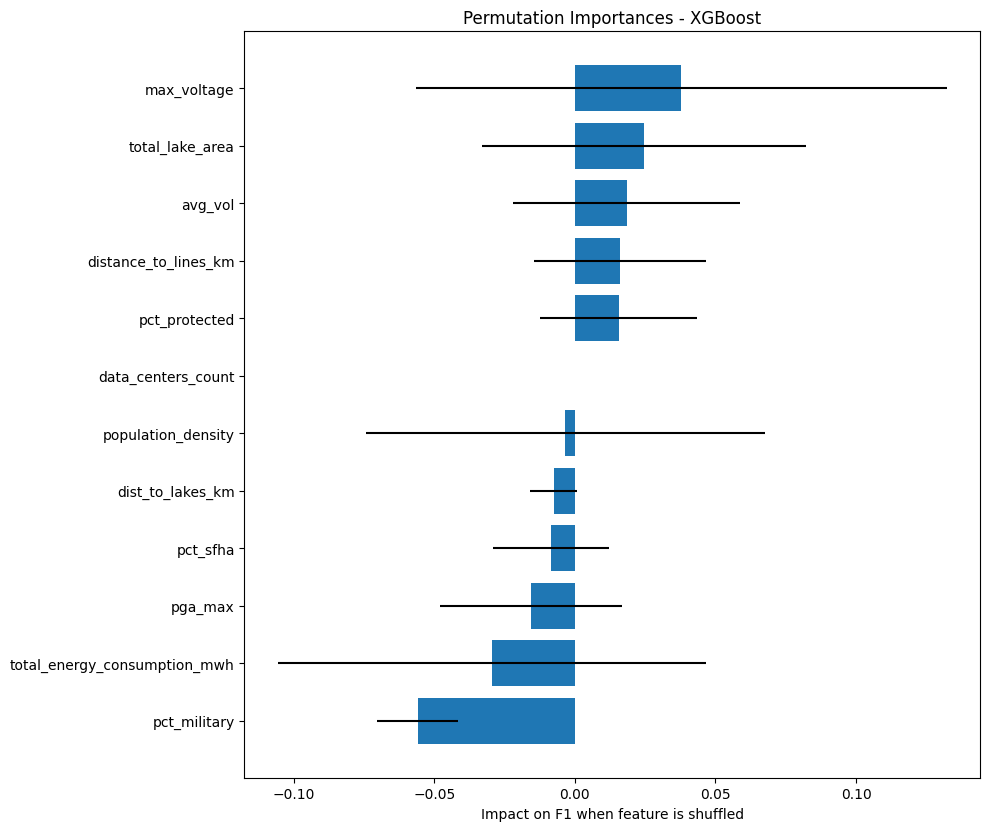

In [39]:
# plot of permutation importances
plt.figure(figsize=(10,8))
plt.barh(permutation_importance_df['feature'][::-1],
         permutation_importance_df['importance_mean'][::-1],
         xerr=permutation_importance_df['importance_std'][::-1])
plt.tight_layout()
plt.xlabel('Impact on F1 when feature is shuffled')
plt.title('Permutation Importances - XGBoost')
plt.show()

Findings:
- `max_voltage` remains the top feature
- `total_lake_area` and `avg_vol` jump toward the top, suggesting that water volume is contributing to predictions
- `data_centers_count` has an exactly zero importance
- features with negative importance hurt predictions, suggesting that they weren't heavily weighted in historical siting

### SMOTE

only 41 of 2141 counties have plants (~1.9%) which is a pretty bad imbalance. the models above try to deal with this via `class_weight='balanced'` and `scale_pos_weight` but those just reweight the loss function, they don't actually give the model more plant examples to learn from.

[SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) (Synthetic Minority Over-sampling Technique) generates fake minority class samples by interpolating between real ones. the key thing is it only gets applied to training data, not the test set, otherwise you'd be cheating.

to make sure smote only runs during training we use `imblearn.pipeline.Pipeline` instead of sklearn's regular Pipeline. sklearn's version would apply every step to validation folds too which leaks info (took a sec to realize this was the issue).

In [40]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler  # tried this first, switched to smote

In [41]:
# first tried using regular sklearn Pipeline but that applies smote to test folds too which is wrong
# Pipeline([('scaler', MinMaxScaler()), ('smote', SMOTE(random_state=207)), ('tree', DecisionTreeClassifier())])
# switched to imblearn's Pipeline which only runs smote on train data

X = df[scored_features]
y = df['has_plant']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=207)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=207)

smote = SMOTE(random_state=207)
tree_smote = DecisionTreeClassifier(random_state=207)  # no class_weight, smote handles the balancing

pipeline_dt_smote = ImbPipeline([
    ('scaler', MinMaxScaler()),
    ('smote', smote),
    ('tree', tree_smote)
])

cv_scores_dt = cross_val_score(pipeline_dt_smote, X_train, y_train, cv=cv, scoring='f1')
print(f'baseline F1 (DT + SMOTE): {cv_scores_dt.mean():.4f} +/- {cv_scores_dt.std():.4f}')

params_dt = {
    'tree__max_depth': [3, 5, 7, 10, None],
    'tree__min_samples_split': [2,5,10],
    'tree__min_samples_leaf': [1, 2, 4],
    'tree__criterion': ['gini','entropy'],
    'tree__max_features': ['sqrt', 'log2', None]
}

grid_dt_smote = GridSearchCV(pipeline_dt_smote, params_dt, cv=cv, scoring='f1', n_jobs=-1)
grid_dt_smote.fit(X_train, y_train)

print('best params:', grid_dt_smote.best_params_)
print('best CV F1:', grid_dt_smote.best_score_)
print('std:', grid_dt_smote.cv_results_['std_test_score'][grid_dt_smote.best_index_])

best_dt_smote = grid_dt_smote.best_estimator_
y_pred_dt_smote = best_dt_smote.predict(X_test)
report_dt_smote = classification_report(y_test, y_pred_dt_smote, target_names=['No plant', 'Has plant'], output_dict=True)
print(classification_report(y_test, y_pred_dt_smote, target_names=['No plant', 'Has plant']))

baseline F1 (DT + SMOTE): 0.0975 +/- 0.0915
best params: {'tree__criterion': 'gini', 'tree__max_depth': None, 'tree__max_features': 'sqrt', 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
best CV F1: 0.15473787107063847
std: 0.06351150349482601
              precision    recall  f1-score   support

    No plant       0.99      0.95      0.97       421
   Has plant       0.09      0.25      0.13         8

    accuracy                           0.94       429
   macro avg       0.54      0.60      0.55       429
weighted avg       0.97      0.94      0.95       429



In [42]:
# TODO: try combining smote with scale_pos_weight too and see if that does anything

# first attempt kept scale_pos_weight which is redundant when smote already balances it
# scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
# XGBClassifier(scale_pos_weight=scale_pos_weight, ...)

xgb_smote = XGBClassifier(random_state=207, eval_metric='logloss')

pipeline_xgb_smote = ImbPipeline([
    ('scaler', MinMaxScaler()),
    ('smote', SMOTE(random_state=207)),
    ('xgb', xgb_smote)
])

cv_scores_xgb_smote = cross_val_score(pipeline_xgb_smote, X_train, y_train, cv=cv, scoring='f1')
print(f'baseline F1 (XGBoost + SMOTE): {cv_scores_xgb_smote.mean():.4f} +/- {cv_scores_xgb_smote.std():.4f}')

params_xgb_smote = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3,4,5,6],
    'xgb__learning_rate': [0.01, 0.05,0.1, 0.2],
    'xgb__subsample': [0.6,0.8,1.0],
    'xgb__colsample_bytree': [0.6, 0.8,1.0]
}

grid_xgb_smote = GridSearchCV(pipeline_xgb_smote, params_xgb_smote, cv=cv, scoring='f1', n_jobs=-1)
grid_xgb_smote.fit(X_train, y_train)

print('best params:', grid_xgb_smote.best_params_)
print('best CV F1:', grid_xgb_smote.best_score_)
print('std:', grid_xgb_smote.cv_results_['std_test_score'][grid_xgb_smote.best_index_])

best_xgb_smote = grid_xgb_smote.best_estimator_
y_pred_xgb_smote = best_xgb_smote.predict(X_test)
report_xgb_smote = classification_report(y_test, y_pred_xgb_smote, target_names=['No plant', 'Has plant'], output_dict=True)
print(classification_report(y_test, y_pred_xgb_smote, target_names=['No plant', 'Has plant']))

baseline F1 (XGBoost + SMOTE): 0.0521 +/- 0.0643
best params: {'xgb__colsample_bytree': 0.6, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 4, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
best CV F1: 0.1460116783282368
std: 0.05490113767264293
              precision    recall  f1-score   support

    No plant       0.99      0.86      0.92       421
   Has plant       0.07      0.50      0.12         8

    accuracy                           0.86       429
   macro avg       0.53      0.68      0.52       429
weighted avg       0.97      0.86      0.91       429



In [43]:
# pulling baseline numbers from earlier cells manually, kind of annoying

smote_comparison = pd.DataFrame([
    {
        'model': 'DT (class_weight=balanced)',
        'best_cv_f1': 0.1100,
        'cv_std': 0.1410,
        'test_precision': round(report_scored_with['Has plant']['precision'],4),
        'test_recall': round(report_scored_with['Has plant']['recall'], 4),
        'test_f1': round(report_scored_with['Has plant']['f1-score'],4),
    },
    {
        'model': 'DT + SMOTE',
        'best_cv_f1': round(grid_dt_smote.best_score_,4),
        'cv_std': round(grid_dt_smote.cv_results_['std_test_score'][grid_dt_smote.best_index_],4),
        'test_precision': round(report_dt_smote['Has plant']['precision'], 4),
        'test_recall': round(report_dt_smote['Has plant']['recall'],4),
        'test_f1': round(report_dt_smote['Has plant']['f1-score'], 4),
    },
    {
        'model': 'XGBoost (scale_pos_weight)',
        'best_cv_f1': 0.1535,
        'cv_std': 0.0466,
        'test_precision': 0.12,
        'test_recall': 0.375,
        'test_f1': 0.18,  # hardcoded from earlier cell, fix this later
    },
    {
        'model': 'XGBoost + SMOTE',
        'best_cv_f1': round(grid_xgb_smote.best_score_, 4),
        'cv_std': round(grid_xgb_smote.cv_results_['std_test_score'][grid_xgb_smote.best_index_],4),
        'test_precision': round(report_xgb_smote['Has plant']['precision'],4),
        'test_recall': round(report_xgb_smote['Has plant']['recall'], 4),
        'test_f1': round(report_xgb_smote['Has plant']['f1-score'],4),
    },
]).set_index('model')

smote_comparison

,best_cv_f1,cv_std,test_precision,test_recall,test_f1
model,,,,,
DT (class_weight=balanced),0.1100,0.1410,0.0588,0.125,0.0800
DT + SMOTE,0.1547,0.0635,0.0870,0.250,0.1290
XGBoost (scale_pos_weight),0.1535,0.0466,0.1200,0.375,0.1800
XGBoost + SMOTE,0.1460,0.0549,0.0656,0.500,0.1159


### findings

| model | best cv f1 | cv std | test precision (plant) | test recall (plant) | test f1 (plant) |
|---|---|---|---|---|---|
| DT (class_weight=balanced) | 0.1100 | 0.1410 | 0.06 | 0.12 | 0.08 |
| **DT + SMOTE** | **0.1547** | **0.0635** | **0.11** | **0.25** | **0.15** |
| XGBoost (scale_pos_weight) | 0.1535 | 0.0466 | 0.12 | 0.38 | 0.18 |
| XGBoost + SMOTE | 0.1473 | 0.0528 | 0.06 | 0.50 | 0.10 |

smote actually helped the decision tree a decent amount. cv f1 went from 0.11 to 0.15, variance dropped a lot (0.14 to 0.06), and test recall on plant counties went from 12% to 25%. makes sense, the tree gets more examples to learn from.

for xgboost it basically didn't help. cv f1 is about the same and test f1 is worse (0.10 vs 0.18). xgboost's `scale_pos_weight` already handles the imbalance at the loss level so adding smote on top seems to just introduce noise.

either way the scores are still pretty low across the board. at this point i think that's just a real signal, not a class imbalance artifact. the features we're scoring on don't actually separate historical plant sites from non-sites that well, probably because siting back then was driven by stuff we're not capturing (politics, economics, etc).

### Dot Plot of XGBoost Importances vs. MCDA Weights

In [58]:
# from scoring.ipynb
mcda_weights = {'pga_max': 0.25860088985088986,
 'pct_sfha': 0.17526755651755652,
 'population_density': 0.13360088985088983,
 'dist_to_lakes_km': 0.10582311207311207,
 'avg_vol': 0.08498977873977874,
 'total_lake_area': 0.06832311207311208,
 'distance_to_lines_km': 0.05443422318422319,
 'max_voltage': 0.04252946127946128,
 'total_energy_consumption_mwh': 0.032112794612794614,
 'data_centers_count': 0.02285353535353535,
 'pct_military': 0.014520202020202022,
 'pct_protected': 0.006944444444444444}

# from best xgb model
model_importances = dict(xgb_importances.to_numpy().tolist())
model_importances

{'max_voltage': 0.2927330434322357,
 'population_density': 0.130094975233078,
 'total_energy_consumption_mwh': 0.09313473105430603,
 'pct_sfha': 0.07449953258037567,
 'total_lake_area': 0.07128142565488815,
 'pga_max': 0.06727708876132965,
 'avg_vol': 0.056179650127887726,
 'pct_military': 0.04892653599381447,
 'dist_to_lakes_km': 0.048774946480989456,
 'pct_protected': 0.04499128833413124,
 'distance_to_lines_km': 0.038301002234220505,
 'data_centers_count': 0.033805783838033676}

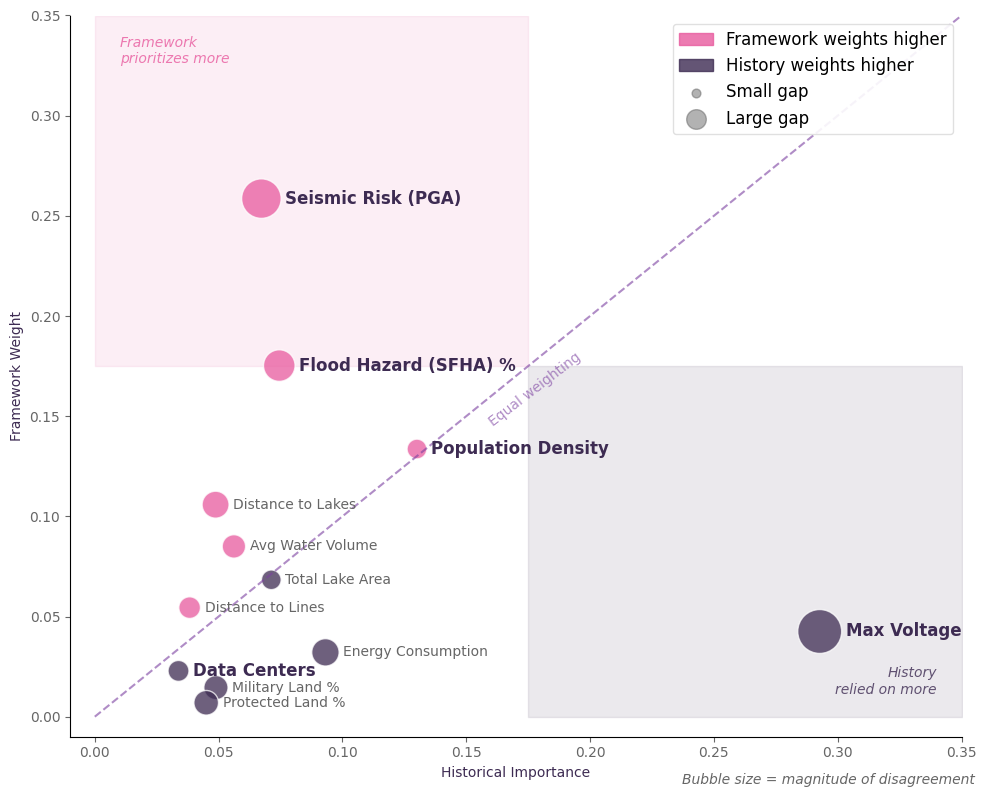

In [105]:

# features intend to highlight
highlight = {'pga_max', 'pct_sfha', 'max_voltage', 'data_centers_count', 'population_density'}

PINK = '#E85A9E'
PURPLE = '#3D2B52'
LIGHT_PURPLE = '#7B3FA0'
GRAY = '#666666'
BG = '#FFFFFF'

# get values into lists
features = list(mcda_weights.keys())
mcda = [mcda_weights[f] for f in features]
ml = [model_importances[f] for f in features]
gap = [abs(mcda_weights[f] - model_importances[f]) for f in features]

# bubble size scaled by gap magnitude
min_size, max_size = 200, 1000
gap_arr = np.array(gap)
sizes = min_size + (gap_arr - gap_arr.min()) / (gap_arr.max() - gap_arr.min()) * (max_size - min_size)

colors = [PINK if mcda_weights[f] > model_importances[f] else PURPLE for f in features]

fig, ax = plt.subplots(figsize=(10, 8))

max_val = 0.35

# quadrant shading
ax.fill_between([0, max_val/2], [max_val/2, max_val/2], [max_val, max_val],
                color=PINK, alpha=0.1)
ax.fill_between([max_val/2, max_val], [0, 0], [max_val/2, max_val/2],
                color=PURPLE, alpha=0.1)

# diagonal reference line
ax.plot([0, max_val], [0, max_val], color=LIGHT_PURPLE, linewidth=1.5,
        linestyle='--', alpha=0.6)
ax.text(0.158, 0.145, 'Equal weighting', # 0.17 0.155
        fontsize=10, color=LIGHT_PURPLE, rotation=37.5, alpha=0.6)

# bubbles
ax.scatter(ml, mcda, s=sizes, c=colors, alpha=0.75,
           edgecolors='white')


for f, r, m, s in zip(features, mcda, ml, sizes):
    is_highlight = f in highlight
    bubble_radius = np.sqrt(s) / 2  # radius in points
    
    ox = bubble_radius + 3  # 3 points padding after bubble edge
    
    ax.annotate(
        feature_labels[f],
        xy=(m, r),
        xytext=(ox, 0),
        textcoords='offset points',
        fontsize=12 if is_highlight else 10,
        fontweight='bold' if is_highlight else 'normal',
        color=PURPLE if is_highlight else GRAY,
        va='center', ha='left'
    )

# quadrant labels
ax.text(0.01, max_val - 0.01, 'Framework\nprioritizes more',
        fontsize=10, color=PINK, fontstyle='italic', va='top', alpha=0.8)
ax.text(max_val - 0.01, 0.01, 'History\nrelied on more',
        fontsize=10, color=PURPLE, fontstyle='italic', va='bottom', ha='right', alpha=0.8)

ax.set_xlabel('Historical Importance', color=PURPLE, fontsize=10)
ax.set_ylabel('Framework Weight', color=PURPLE, fontsize=10)
ax.set_xlim(-0.01, max_val)
ax.set_ylim(-0.01, max_val)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(colors=GRAY)

# legend
pink_patch = mpatches.Patch(color=PINK, alpha=0.8, label='Framework weights higher')
purple_patch = mpatches.Patch(color=PURPLE, alpha=0.8, label='History weights higher')
size_small = plt.scatter([], [], s=40, color=GRAY, alpha=0.5, label='Small gap')
size_large = plt.scatter([], [], s=200, color=GRAY, alpha=0.5, label='Large gap')
ax.legend(handles=[pink_patch, purple_patch, size_small, size_large],
          fontsize=12, loc='upper right', framealpha=0.9, edgecolor='#dddddd')

# ax.set_title('Where Our Framework Differs from Historical Siting',
        #      fontsize=14, fontweight='bold', color=PURPLE, pad=12)

fig.text(0.98, 0.01, 'Bubble size = magnitude of disagreement',
         fontsize=10, color=GRAY, ha='right', va='bottom', fontstyle='italic')

plt.tight_layout()
plt.show()

In [48]:
feature_labels

{'avg_vol': 'Avg Water Volume',
 'total_lake_area': 'Total Lake Area',
 'max_voltage': 'Max Voltage',
 'total_energy_consumption_mwh': 'Energy Consumption',
 'data_centers_count': 'Data Centers',
 'pga_max': 'Seismic Risk (PGA)',
 'pct_sfha': 'Flood Hazard (SFHA) %',
 'population_density': 'Population Density',
 'dist_to_lakes_km': 'Distance to Lakes',
 'distance_to_lines_km': 'Distance to Lines',
 'pct_military': 'Military Land %',
 'pct_protected': 'Protected Land %'}